In [ ]:
"""
🎭 EMOTION RECOGNITION - COMPLETE CODE (FIXED)
"""

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/out_nonhijabi"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ====================================
# Configuration
# ====================================
DATA_PATH = "/content/drive/MyDrive/out_nonhijabi"
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.0001
NUM_CLASSES = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# ====================================
# Data Transforms
# ====================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# ====================================
# Load Dataset
# ====================================
print("\n📂 Loading dataset...")
full_dataset = datasets.ImageFolder(DATA_PATH, transform=test_transform)

targets = np.array(full_dataset.targets)
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transform

val_dataset = Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"📊 Dataset Statistics:")
print(f"  Total: {len(full_dataset)}")
print(f"  Training: {len(train_dataset)}")
print(f"  Validation: {len(val_dataset)}")
print(f"  Classes: {full_dataset.classes}")

# ====================================
# Build Model
# ====================================
def build_model(num_classes=5, pretrained=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )
    return model

model = build_model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ✅ Fixed Scheduler (no verbose parameter)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

print("\n✅ Model ready!")
print(f"📊 Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ====================================
# Training Functions
# ====================================
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

# ====================================
# Training Loop
# ====================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, save_path='/content/drive/MyDrive/'):
    print("\n🏋️ Starting Training...\n")

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"{'='*60}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']

        if new_lr < old_lr:
            print(f"\n📉 Learning Rate Reduced: {old_lr:.2e} → {new_lr:.2e}")

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(new_lr)

        print(f"\n📊 Summary:")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"  Val: Loss={val_loss:.4f}, Acc={val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_to_idx': full_dataset.class_to_idx
            }, os.path.join(save_path, 'best_resnet18_emotion.pth'))
            print(f"  ✅ Best model saved! (Acc: {val_acc:.2f}%)")

    print(f"\n✅ Training Complete! Best Acc: {best_val_acc:.2f}%")
    return history

# ====================================
# Start Training
# ====================================
history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=NUM_EPOCHS, device=device
)

print("\n🎉 Project completed successfully!")


Mounted at /content/drive
🖥️  Device: cuda

📂 Loading dataset...
📊 Dataset Statistics:
  Total: 1250
  Training: 1000
  Validation: 250
  Classes: ['angry', 'happy', 'neutral', 'sad', 'surprise']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]



✅ Model ready!
📊 Parameters: 11,179,077

🏋️ Starting Training...


Epoch 1/50 | LR: 1.00e-04


Validation: 100%|██████████| 8/8 [01:08<00:00,  8.51s/it, loss=1.3370, acc=46.80%]



📊 Summary:
  Train: Loss=1.6418, Acc=29.90%
  Val: Loss=1.2831, Acc=46.80%
  ✅ Best model saved! (Acc: 46.80%)

Epoch 2/50 | LR: 1.00e-04


...


📉 Learning Rate Reduced: 3.13e-06 → 1.56e-06

📊 Summary:
  Train: Loss=0.0142, Acc=99.80%
  Val: Loss=1.1757, Acc=67.60%

Epoch 49/50 | LR: 1.56e-06


Validation: 100%|██████████| 8/8 [00:01<00:00,  5.22it/s, loss=2.0554, acc=66.80%]



📊 Summary:
  Train: Loss=0.0177, Acc=99.70%
  Val: Loss=1.1871, Acc=66.80%

Epoch 50/50 | LR: 1.56e-06


Validation: 100%|██████████| 8/8 [00:01<00:00,  4.99it/s, loss=2.2250, acc=65.60%]


📊 Summary:
  Train: Loss=0.0138, Acc=100.00%
  Val: Loss=1.2141, Acc=65.60%

✅ Training Complete! Best Acc: 69.20%

🎉 Project completed successfully!


In [ ]:
import torch
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import DataLoader
import numpy as np

# ====================================
# Load best model
# ====================================
checkpoint = torch.load('/content/drive/MyDrive/best_resnet18_emotion.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # وضع evaluation

# ====================================
# Evaluate on validation set
# ====================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ====================================
# Metrics
# ====================================
print("\n📊 Validation Metrics:")
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy*100:.2f}%\n")

# Classification report (Precision, Recall, F1)
report = classification_report(all_labels, all_preds, target_names=full_dataset.classes)
print(report)


📊 Validation Metrics:
Accuracy: 63.60%

              precision    recall  f1-score   support

       angry       0.61      0.50      0.55        50
       happy       0.79      0.82      0.80        50
     neutral       0.45      0.40      0.43        50
         sad       0.52      0.66      0.58        50
    surprise       0.82      0.80      0.81        50

    accuracy                           0.64       250
   macro avg       0.64      0.64      0.63       250
weighted avg       0.64      0.64      0.63       250



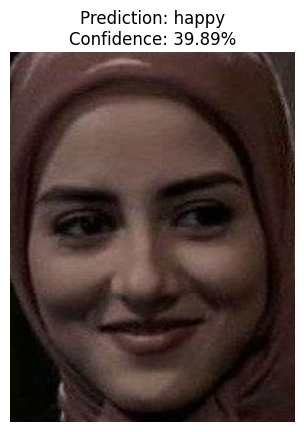

Predicted Emotion: happy
Confidence: 39.89%


In [ ]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# ====================================
# Load trained model
# ====================================
checkpoint = torch.load('/content/drive/MyDrive/best_resnet18_emotion.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ====================================
# Test new image
# ====================================
IMAGE_PATH = '/content/Screenshot 2025-12-05 001456.png'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# فتح الصورة وتحويلها للتنسور
img = Image.open(IMAGE_PATH)
img_tensor = transform(img).unsqueeze(0).to(device)

# التنبؤ
with torch.no_grad():
    output = model(img_tensor)
    probabilities = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

class_names = full_dataset.classes  # أو ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise'] حسب التدريب

# عرض النتيجة
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[predicted_class]}\nConfidence: {probabilities[0][predicted_class]*100:.2f}%")
plt.show()

print(f"Predicted Emotion: {class_names[predicted_class]}")
print(f"Confidence: {probabilities[0][predicted_class]*100:.2f}%")

Using device: cuda
Hijabi Dataset: 1250 images
Classes: ['Sad', 'angry', 'happy', 'natural', 'surprised']

Overall Accuracy: 27.04%

Classification Report:
              precision    recall  f1-score   support

         Sad     0.1959    0.2320    0.2125       250
       angry     0.0000    0.0000    0.0000       250
       happy     0.1719    0.1526    0.1617       249
     natural     0.2663    0.6016    0.3692       251
   surprised     0.5583    0.3640    0.4407       250

    accuracy                         0.2704      1250
   macro avg     0.2385    0.2700    0.2368      1250
weighted avg     0.2386    0.2704    0.2370      1250



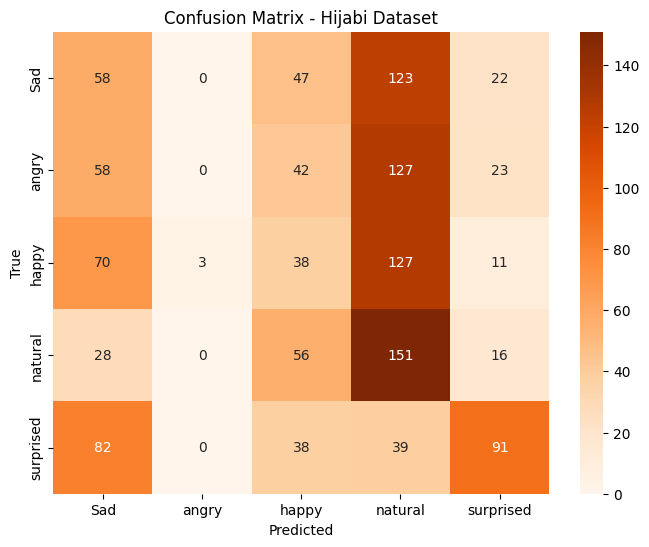

In [5]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ====================================
# Configuration
# ====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# مسار الموديل
model_path = '/content/drive/MyDrive/best_resnet18_emotion.pth'

# مجلد الصور المحجبات
HIJABI_DATA_PATH = '/content/drive/MyDrive/Emotion_hijabi'  # غيّري حسب مجلدك

# ====================================
# Load Model
# ====================================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(num_features, 5)  # 5 emotions
)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# ====================================
# Data Transform for Hijabi Images
# ====================================
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load hijabi dataset
hijabi_dataset = datasets.ImageFolder(HIJABI_DATA_PATH, transform=test_transform)
hijabi_loader = DataLoader(hijabi_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Hijabi Dataset: {len(hijabi_dataset)} images")
print("Classes:", hijabi_dataset.classes)
class_names = hijabi_dataset.classes

# ====================================
# Run predictions
# ====================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in hijabi_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ====================================
# Metrics
# ====================================
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%\n")

print("Classification Report:")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# ====================================
# Confusion Matrix (Optional)
# ====================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Hijabi Dataset')
plt.show()